Theme: Student Performance Analysis & Prediction


In [5]:
# ============================================
# Task 1 — Data Exploration with Pandas
# ============================================

# Import required library
import pandas as pd

# -----------------------------
#  Load Dataset
# -----------------------------
df = pd.read_csv("students.csv")

# -----------------------------
# Step 1: Display first 5 rows
# -----------------------------
print("First 5 rows of dataset:")
print(df.head())


# -----------------------------
# Step 2: Shape and Data Types
# -----------------------------
print("\nDataset Shape (Rows, Columns):")
print(df.shape)

print("\nData Types of each column:")
print(df.dtypes)


# -----------------------------
# Step 3: Summary Statistics
# -----------------------------
print("\nSummary Statistics:")
print(df.describe())


# -----------------------------
# Step 4: Pass/Fail Count
# -----------------------------
print("\nCount of Passed vs Failed students:")
print(df['passed'].value_counts())


# -----------------------------
# Step 5: Average Scores (Pass vs Fail)
# -----------------------------
subject_cols = ['math', 'science', 'english', 'history', 'pe']

# Average scores of students who passed
pass_avg = df[df['passed'] == 1][subject_cols].mean()

# Average scores of students who failed
fail_avg = df[df['passed'] == 0][subject_cols].mean()

print("\nAverage scores of PASSING students:")
print(pass_avg)

print("\nAverage scores of FAILING students:")
print(fail_avg)


# -----------------------------
# Step 6: Student with Highest Average
# -----------------------------
# Create a new column for average marks
df['average_score'] = df[subject_cols].mean(axis=1)

# Find student with highest average
top_student = df.loc[df['average_score'].idxmax()]

print("\nStudent with highest average score:")
print(top_student[['name', 'average_score']])


First 5 rows of dataset:
      name  math  science  english  history  pe  attendance_pct  \
0    Alice    88       92       76       80  95              92   
1      Bob    42       55       48       50  60              65   
2  Charlie    75       70       80       68  88              85   
3    Diana    95       98       91       89  97              98   
4      Eve    38       42       50       45  55              58   

   study_hours_per_day  passed  
0                  4.5       1  
1                  1.2       0  
2                  3.0       1  
3                  6.0       1  
4                  0.8       0  

Dataset Shape (Rows, Columns):
(15, 9)

Data Types of each column:
name                       str
math                     int64
science                  int64
english                  int64
history                  int64
pe                       int64
attendance_pct           int64
study_hours_per_day    float64
passed                   int64
dtype: object

Summary Stat

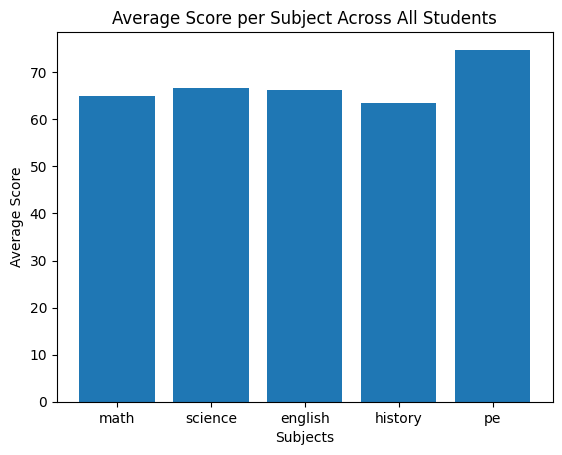

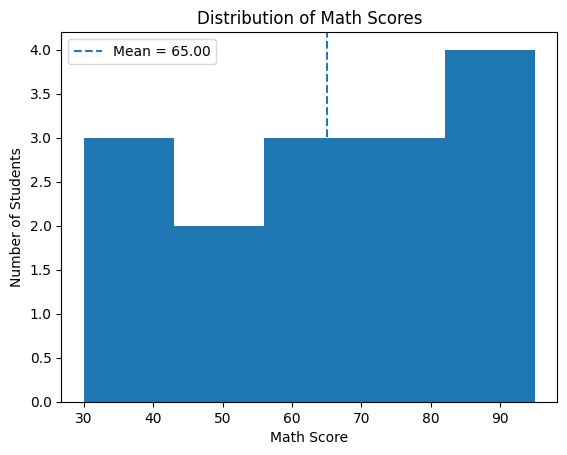

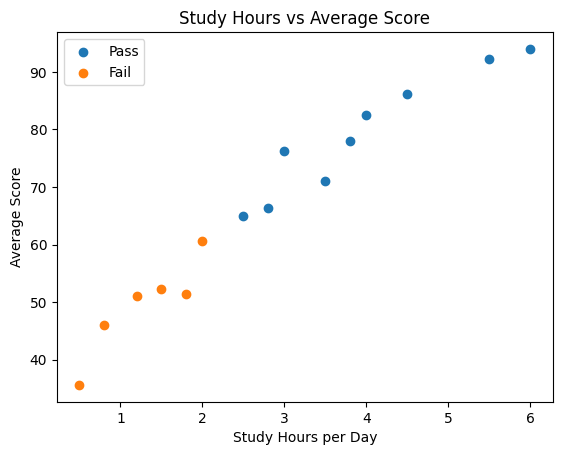

/var/folders/gn/kmvhn9ds791983thqnsjgz7r0000gn/T/ipykernel_2481/4261203416.py:95: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([pass_attendance, fail_attendance], labels=['Pass', 'Fail'])


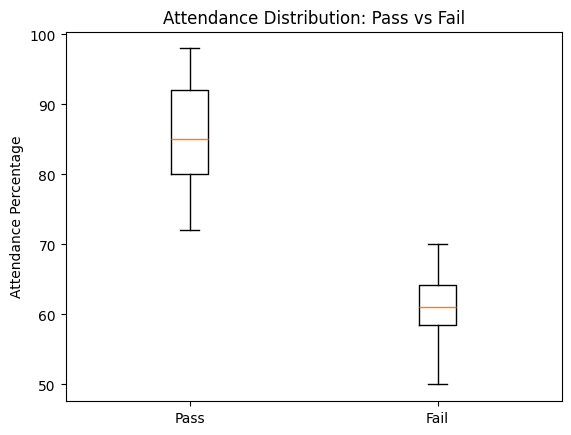

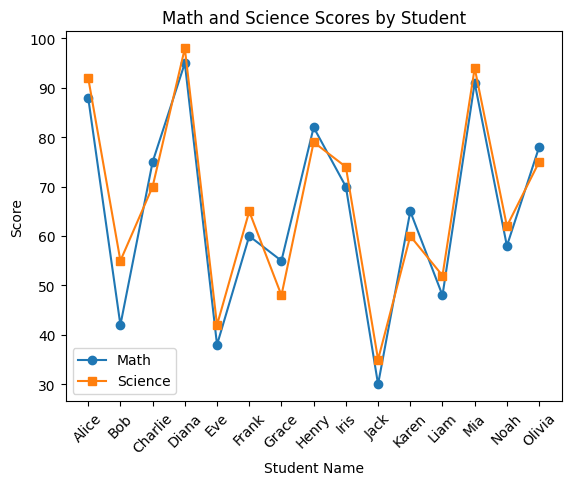

In [6]:
# -----------------------------
# Task 2 — Data Visualization with Matplotlib
# -----------------------------

import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Load dataset

df = pd.read_csv("students.csv")

# Step 2: Create average score column

subject_cols = ['math', 'science', 'english', 'history', 'pe']
df['avg_score'] = df[subject_cols].mean(axis=1)


# =============================
# 1. Bar Chart — Avg Score per Subject
# =============================

# calculating average marks for each subject

avg_scores = df[subject_cols].mean()

plt.figure()
plt.bar(subject_cols, avg_scores)

plt.title("Average Score per Subject Across All Students")
plt.xlabel("Subjects")
plt.ylabel("Average Score")

plt.savefig("plot1_bar.png")
plt.show()


# =============================
# 2. Histogram — Math Scores
# =============================

# plotting distribution of math scores

math_scores = df['math']
mean_math = math_scores.mean()

plt.figure()
plt.hist(math_scores, bins=5)

# adding mean line

plt.axvline(mean_math, linestyle='dashed', label=f"Mean = {mean_math:.2f}")

plt.title("Distribution of Math Scores")
plt.xlabel("Math Score")
plt.ylabel("Number of Students")
plt.legend()

plt.savefig("plot2_histogram.png")
plt.show()


# =============================
# 3. Scatter Plot — Study Hours vs Avg Score
# =============================

# separating pass and fail students

pass_data = df[df['passed'] == 1]
fail_data = df[df['passed'] == 0]

plt.figure()

plt.scatter(pass_data['study_hours_per_day'], pass_data['avg_score'], label="Pass")
plt.scatter(fail_data['study_hours_per_day'], fail_data['avg_score'], label="Fail")

plt.title("Study Hours vs Average Score")
plt.xlabel("Study Hours per Day")
plt.ylabel("Average Score")
plt.legend()

plt.savefig("plot3_scatter.png")
plt.show()


# =============================
# 4. Box Plot — Attendance
# =============================

# comparing attendance of pass vs fail students

pass_attendance = pass_data['attendance_pct'].tolist()
fail_attendance = fail_data['attendance_pct'].tolist()

plt.figure()
plt.boxplot([pass_attendance, fail_attendance], labels=['Pass', 'Fail'])

plt.title("Attendance Distribution: Pass vs Fail")
plt.ylabel("Attendance Percentage")

plt.savefig("plot4_boxplot.png")
plt.show()


# =============================
# 5. Line Plot — Math vs Science
# =============================

# comparing subject scores across students

plt.figure()

plt.plot(df['name'], df['math'], marker='o', label="Math")
plt.plot(df['name'], df['science'], marker='s', label="Science")

plt.title("Math and Science Scores by Student")
plt.xlabel("Student Name")
plt.ylabel("Score")

plt.xticks(rotation=45)
plt.legend()

plt.savefig("plot5_line.png")
plt.show()


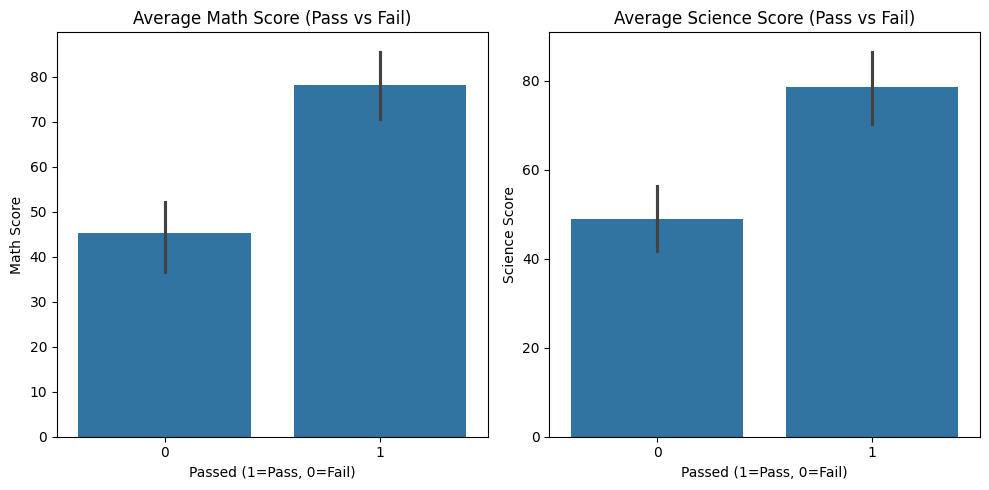

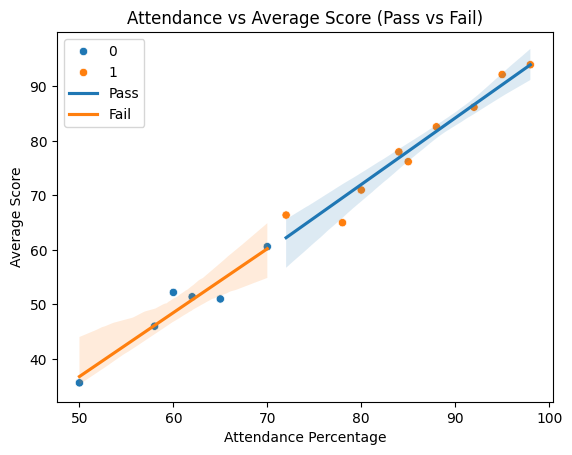

In [7]:
# ---------------------------------------------
# Task 3 — Data Visualization with Seaborn
# --------------------------------------------

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset

df = pd.read_csv("students.csv")

# Create avg_score column (important for scatter plot)

subject_cols = ['math', 'science', 'english', 'history', 'pe']
df['avg_score'] = df[subject_cols].mean(axis=1)


# =============================
# 1. Bar Plot — Math & Science vs Pass/Fail
# =============================

plt.figure(figsize=(10, 5))

# Subplot 1: Math scores
ax1 = plt.subplot(1, 2, 1)
sns.barplot(data=df, x='passed', y='math', ax=ax1)
ax1.set_title("Average Math Score (Pass vs Fail)")
ax1.set_xlabel("Passed (1=Pass, 0=Fail)")
ax1.set_ylabel("Math Score")

# Subplot 2: Science scores
ax2 = plt.subplot(1, 2, 2)
sns.barplot(data=df, x='passed', y='science', ax=ax2)
ax2.set_title("Average Science Score (Pass vs Fail)")
ax2.set_xlabel("Passed (1=Pass, 0=Fail)")
ax2.set_ylabel("Science Score")

plt.tight_layout()
plt.savefig("plot6_seaborn_bar.png")
plt.show()


# =============================
# 2. Scatter Plot — Attendance vs Avg Score
# =============================

plt.figure()

# Scatter plot with hue
sns.scatterplot(data=df, x='attendance_pct', y='avg_score', hue='passed')

# Regression line for Pass students
sns.regplot(
    data=df[df['passed'] == 1],
    x='attendance_pct',
    y='avg_score',
    scatter=False,
    label='Pass'
)

# Regression line for Fail students
sns.regplot(
    data=df[df['passed'] == 0],
    x='attendance_pct',
    y='avg_score',
    scatter=False,
    label='Fail'
)

plt.title("Attendance vs Average Score (Pass vs Fail)")
plt.xlabel("Attendance Percentage")
plt.ylabel("Average Score")
plt.legend()

plt.savefig("plot7_seaborn_scatter.png")
plt.show()


# =============================
# Comparison Comment (VERY IMPORTANT)
# =============================

# In this task, Seaborn felt easier to use for statistical plots compared to Matplotlib.
# The bar plots and scatter plots required less manual styling and looked more professional by default.
# However, Matplotlib provides more control and flexibility, especially for customizing plots in detail.


Training Accuracy: 1.00
Test Accuracy: 1.00

Test Predictions:
Jack | Actual: 0 | Predicted: 0 → ✅ Correct
Liam | Actual: 0 | Predicted: 0 → ✅ Correct
Alice | Actual: 1 | Predicted: 1 → ✅ Correct

Feature Importance (sorted):
english: 0.8125
attendance_pct: 0.5219
study_hours_per_day: 0.4844
pe: 0.4750
math: 0.4379
science: 0.3230
history: 0.2629


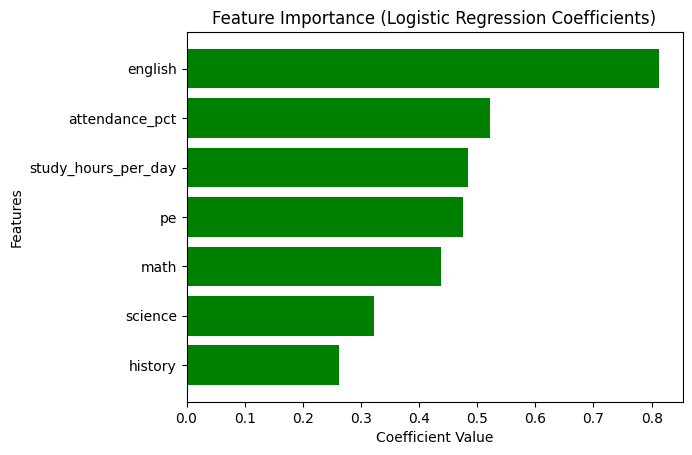


New Student Prediction:
Prediction: Pass
Probability (Fail, Pass): [0.09203526 0.90796474]


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [8]:
# -----------------------------
# Task 4: Machine Learning Model
# -----------------------------

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# -----------------------------
# Step 1: Load Dataset
# -----------------------------
df = pd.read_csv("students.csv")

# Features and Target
feature_cols = ['math', 'science', 'english', 'history', 'pe', 'attendance_pct', 'study_hours_per_day']
X = df[feature_cols]
y = df['passed']

# -----------------------------
# Step 2: Train-Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------------
# Step 3: Feature Scaling
# -----------------------------
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)   # fit only on training data
X_test_scaled = scaler.transform(X_test)

# -----------------------------
# Step 4: Train Model
# -----------------------------
model = LogisticRegression()

model.fit(X_train_scaled, y_train)

# Training accuracy
train_acc = model.score(X_train_scaled, y_train)
print(f"Training Accuracy: {train_acc:.2f}")

# -----------------------------
# Step 5: Evaluate Model
# -----------------------------
y_pred = model.predict(X_test_scaled)

test_acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {test_acc:.2f}")

print("\nTest Predictions:")

# Get student names from original df using index
test_names = df.loc[X_test.index, 'name']

for name, actual, pred in zip(test_names, y_test, y_pred):
    result = "✅ Correct" if actual == pred else "❌ Wrong"
    print(f"{name} | Actual: {actual} | Predicted: {pred} → {result}")

# -----------------------------
# Step 6: Feature Importance
# -----------------------------
coefficients = model.coef_[0]

# Pair feature names with coefficients
feature_importance = list(zip(feature_cols, coefficients))

# Sort by absolute value (most important first)
feature_importance.sort(key=lambda x: abs(x[1]), reverse=True)

print("\nFeature Importance (sorted):")
for feature, coef in feature_importance:
    print(f"{feature}: {coef:.4f}")

# -----------------------------
# Step 7: Plot Feature Importance
# -----------------------------
features = [x[0] for x in feature_importance]
values = [x[1] for x in feature_importance]

# Assign colors
colors = ['green' if v > 0 else 'red' for v in values]

plt.figure()

plt.barh(features, values, color=colors)

plt.title("Feature Importance (Logistic Regression Coefficients)")
plt.xlabel("Coefficient Value")
plt.ylabel("Features")

plt.gca().invert_yaxis()  # highest on top

plt.savefig("plot8_feature_importance.png")
plt.show()

# -----------------------------
# Step 8: Predict New Student
# -----------------------------
# new student data (same order as features)
new_student = [[75, 70, 68, 65, 80, 82, 3.2]]

# scale it
new_student_scaled = scaler.transform(new_student)

# prediction
prediction = model.predict(new_student_scaled)[0]
probability = model.predict_proba(new_student_scaled)[0]

result = "Pass" if prediction == 1 else "Fail"

print("\nNew Student Prediction:")
print(f"Prediction: {result}")
print(f"Probability (Fail, Pass): {probability}")
